In [130]:
%pip install numpy matplotlib ipython ipykernel scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [131]:
import numpy as np
import scipy.stats as stats

import matplotlib.pyplot as plt


# Завдання 1

## Опис

Нехай $ \omega_1 $ та $ \omega_2 $ - це незалежні рівномірно розподілені на $ [0, 1] $ випадкові величини (в.в.), які отримаємо вбудованим генератором випадкових величин.
Пара незалежних в.в. $ ( \xi_1, \xi_2 ) $, які мають стандартний нормальний розподіл (тобто $ N(0, 1) $), генерується за допомогою перетворення:
$$ \xi_1 = \sqrt{-2 \ln{\omega_1}} \sin{(2 \pi \omega_2)}, \xi_2 = \sqrt{-2 \ln{\omega_1}} \cos{(2 \pi \omega_2)} $$
(в.в. $ N(0, 1) $  можна генерувати і за допомогою вбудованого генератора). Позначимо $ a = M(\xi_i) = 0, \sigma^2 = D(\xi_i) = 1 $.

Нехай спостерігається вибірка $ \bar{X} = \left( X_1, K, X_n \right)$, де $ X_i: N(0, 1) $.

Побудувати довірчий інтервал для:
- математичного сподівання $ a $  у припущенні, що спостерігаються в.в. $ \{ X_i \} $, які мають нормальний розподіл, але дисперсія $ \sigma^2 $ невідома;
- математичного сподівання $ a $ у припущенні, що спостерігаються в.в. $ \{ X_i \} $, розподіл яких невідомий.
- дисперсії $ \sigma^2 $ у припущенні, що спостерігаються в.в. $ \{ X_i \} $, які мають нормальний розподіл.

Всі довірчі інтервали будуються із достовірністю $ 1 - \gamma = 0.99 $ для $ n = 10^2 $, $ n = 10^4 $ та $ n = 10^6 $.
В усіх цих випадках дослідити, чи потрапляють математичне сподівання та дисперсія у побудовані довірчі інтервали, а також оцінити, як змінюється довжина довірчого інтервалу при збільшенні $ n $.
Інакше кажучи, виводити на друк:
- кількість виконаних реалізацій;
- отриману оцінку;
- побудований довірчий інтервал;
- ширину довірчого інтервалу.

**Зауваження**. Формули для побудови оцінок та довірчих інтервалів див. лекції 3 та 4.
Для випадку b) краще використовувати незміщену оцінку дисперсії.

## Вимоги

$ 1 - \gamma = 0.99 $  
$ n = 10^2, n = 10^4, n = 10^6 $

Для кожного $ n $ виводити на друк:
- кількість виконаних реалізацій;
- отриману оцінку;
- побудований довірчий інтервал;
- ширину довірчого інтервалу.

## Реалізація

Незміщена оцінка дисперсії: 
$$ \hat{\sigma}_n^2 = \frac{1}{n-1} \sum_{k=1}^{n}{\left(X_k - \left(\frac{1}{n}\sum_{k=1}^{n}{X_k}\right)\right)^2} \xrightarrow[n \to \infty]{} \sigma^2 $$


$\textbf{Довірчий інтервал для м.с. }$ $\mathbf{a}$ $\textbf{ при невідомій дисперсії }$ $\mathbf{\sigma^2}$ $\textbf{.}$ Для побудови довірчого інтервалу скористаємось твердженням леми 2, згідно якого $ \hat{\gamma}_n = \sqrt{n-1}\frac{\hat{a}_n - a}{\hat{\sigma}_n} $ має розподіл Стьюдента з $ n - 1 $ ступенем свободи. Тобто

$$ \textbf{P}\left\{\frac{\sqrt{n-1}}{\hat{\sigma}_n} \left\lvert \hat{a}_n - a \right\rvert < z\right\} = \int_{-z}^{z}{s_{n-1}(u) du} = 2\int_{0}^{z}{s_{n-1}(u) du} = 2 S_{n-1}(u) = 1 - \gamma $$

З останнього рівняння за таблицями для розподілу Стьюдента знаходимо $ z_{\gamma} $.

Маємо

$$ \textbf{P}\left\{\hat{a}_n - \frac{z_{\gamma}}{\sqrt{n-1}}\hat{\sigma}_n < a < \hat{a}_n + \frac{z_{\gamma}}{\sqrt{n-1}}\hat{\sigma}_n \right\} = 1 - \gamma $$

Звідси випливає, що

$$ a \in \left(\hat{a}_n - \frac{z_{\gamma}}{\sqrt{n-1}}\hat{\sigma}_n, \hat{a}_n + \frac{z_{\gamma}}{\sqrt{n-1}}\hat{\sigma}_n \right) \text{ з імовірністю } 1 - \gamma $$

Три відмінності від попереднього випадку: а) замість нормального розподілу використовується розподіл Стьюдента; b) $ \sigma $ замінюється на $ \hat{\sigma}_n $; 
c) $ n $ замінюється на $ n - 1 $.

$\textbf{Асимптотичний довірчий інтервал для математичного сподівання в.в., коли її розподіл невідомий.}$ В основі методу побудови асимптотичних довірчих інтервалів для параметрів, які не можна оцінити середнім арифметичним від нормально розподілених в.в., лежить центральна гранична теорема для незалежних однаково розподілених в.в.: якщо $ X_1, X_2, ... $ - послідовність незалежних однаково розподілених в.в. $ a = \textbf{M} X_i $, $ \sigma^2 = \textbf{D} X_i < \infty $, то

$$ \textbf{P}\left\{\left\lvert \frac{\sum_{i=1}^{n}{X_i} - n a}{\sigma \sqrt{n}} \right\rvert < z\right\} = 2 \Phi(z) $$

де $ \Phi(z) = \frac{1}{\sqrt{2\pi}}\int_{0}^{z}{e^{-\frac{u^2}{2}} du} $ – функція Лапласа. Позначимо $ \hat{a}_n = \frac{1}{n}\sum_{k=1}^{n}{X_k} $. Якщо $ z_{\gamma} $ - розв'язок рівняння $ 2 \Phi(z) = 1 - \gamma $, то маємо довірчий інтервал:

$$ a \in \left(\hat{a}_n - \frac{z_{\gamma} \sigma}{\sqrt{n}}, \hat{a}_n + \frac{z_{\gamma} \sigma}{\sqrt{n}} \right) \text{ з ймовірністю } 1 - \gamma $$

Оскільки, як правило, знайти точне значення дисперсії $ \sigma^2 $ немає жодної можливості, то на практиці у наведеній вище формулі використовують незміщену оцінку дисперсії: $ \hat{\sigma}_n^2 = \frac{1}{n-1} \sum_{k=1}^{n}{\left(X_k - \left(\frac{1}{n}\sum_{k=1}^{n}{X_k}\right)\right)^2} \xrightarrow[n \to \infty]{} \sigma^2 $. Тоді асимптотичний довірчий інтервал приймає вигляд:

$$ a \in \left(\hat{a}_n - \frac{z_{\gamma} \hat{\sigma}_n}{\sqrt{n}}, \hat{a}_n + \frac{z_{\gamma} \hat{\sigma}_n}{\sqrt{n}} \right) \text{ з ймовірністю } 1 - \gamma $$

$ \textbf{Довірчий інтервал для дисперсії}$ $\mathbf{\sigma^2}$ $ \textbf{.} $ Згідно з другою частиною леми 1 $ \hat{V}_n = \frac{n\hat{\sigma}_n^2}{\sigma^2} = \chi_{n-1}^{2} $, тобто має розподіл $ \chi^{2} $  з $ n-1 $ ступенем свободи. Нехай $ 1 - \gamma $ - це коефіцієнт довіри. Визначимо значення $ z_{\gamma n}^{(1)} $ та $ z_{\gamma n}^{(2)} $ з рівняння

$$ \int_{z_{\gamma n}^{(1)}}^{z_{\gamma n}^{(2)}}{t_{n-1}(u) du} = 1 - \gamma $$

Очевидно, що числа $ z_{\gamma n}^{(1)} $ та $ z_{\gamma n}^{(2)} $ визначаються неоднозначно. Тому додатково вимагаємо:

$$ \int_{0}^{z_{\gamma n}^{(1)}}{t_{n-1}(u) du} = \frac{\gamma}{2}, \qquad \int_{z_{\gamma n}^{(2)}}^{\infty}{t_{n-1}(u) du} = \frac{\gamma}{2} $$

У цьому випадку числа $ z_{\gamma n}^{(1)} $ та $ z_{\gamma n}^{(2)} $ визначаються однозначно. Їхні значення знаходять з таблиць $ \chi^{2} $ розподілу з $ n-1 $ ступенем свободи. Таким чином, маємо:

$$ \textbf{P}\left\{ z_{\gamma n}^{(1)} < \frac{n \hat{\sigma}_n^2}{\sigma^2} < z_{\gamma n}^{(2)} \right\} = \int_{z_{\gamma n}^{(1)}}^{z_{\gamma n}^{(2)}}{t_{n-1}(u) du} = 1 - \gamma $$

Звідси маємо: $ \frac{n \hat{\sigma}_n^2}{z_{\gamma n}^{(2)}} < \sigma^2 < \frac{n \hat{\sigma}_n^2}{z_{\gamma n}^{(1)}} $ з ймовірністю $ 1 - \gamma $.

In [132]:
class InfoTask1:
    title = ""
    n = -1
    estimation = 0.0
    interval = [0.0, 0.0]

    @property
    def width(self):
        return self.interval[1] - self.interval[0]
    
    def print_info(self, suptitle: str = ""):
        width_separate = 100
        print(self.title)
        print("_"*width_separate)
        print(f"[Кількість виконаних реалізацій] n = {self.n}")
        print("_"*width_separate)
        print(f"[Отримана оцінка] {self.estimation}")
        print(f"[Довірчий інтервал] {self.interval}")
        print(f"[Ширина довірчого інтервалу] {self}")
        print("_"*width_separate)
        print("\n")
        plt.ylim(-0.5, 0.5)
        plt.yticks([])
        plt.plot(self.interval, [0, 0], color='blue', zorder=1, marker='|', markersize=16)
        plt.scatter(self.estimation, 0, color='red', zorder=2)
        y_offset = 0.05 
        plt.text(self.interval[0], 2*y_offset, f"{self.interval[0]:.4f}", ha='center', va='bottom', color='blue')
        plt.text(self.interval[1], -2*y_offset, f"{self.interval[1]:.4f}", ha='center', va='top', color='blue')
        plt.text(self.estimation, -0.5*y_offset, f"{self.estimation:.4f}", ha='center', va='top', color='red')
        plt.title(f"Довірчий інтервал для {suptitle} n = {self.n}")
        plt.show()

def generate_data(n):
    amount = n // 2
    w1 = np.random.uniform(0, 1, amount)
    w2 = np.random.uniform(0, 1, amount)
    
    xi_1 = np.sqrt(-2 * np.log(w1)) * np.sin(2 * np.pi * w2)
    xi_2 = np.sqrt(-2 * np.log(w1)) * np.cos(2 * np.pi * w2)
    return np.concatenate((xi_1, xi_2))

def _interval(interval, info):
    if info is not None:
        info.interval = interval
    return interval


# довірчий інтервал для математичного сподівання $ a $  у припущенні, що спостерігаються в.в. $ \{ X_i \} $, які мають нормальний розподіл, але дисперсія $ \sigma^2 $ невідома;
def normal_distribution_mean_estimation_without_known_variance(n: float, gamma: float, X_mean: float, sigma: float, info: Info = None) -> list[float]:
    """
    a) Довірчий інтервал для математичного сподівання при невідомій дисперсії (Через розподіл Стьюдента)
    """
    z_value = stats.t.ppf(1 - gamma / 2, n - 1)
    a = z_value * sigma / np.sqrt(n - 1)
    interval = [X_mean - a, X_mean + a]
    return _interval(interval, info)

# довірчий інтервал для математичного сподівання $ a $ у припущенні, що спостерігаються в.в. $ \{ X_i \} $, розподіл яких невідомий.
def unknown_distribution_mean_estimation(n: float, gamma: float, X_mean: float, sigma: float, info: Info = None) -> list[float]:
    """
    b) Довірчий інтервал для математичного сподівання при невідомому розподілі (Через асимптотичний довірчий інтервал для математичного сподівання в.в., коли її розподіл невідомий)
    """
    z_value = stats.norm.ppf(1 - gamma / 2)
    a = z_value * sigma / np.sqrt(n)
    interval = [X_mean - a, X_mean + a]
    return _interval(interval, info)

# довірчий інтервал для дисперсії $ \sigma^2 $ у припущенні, що спостерігаються в.в. $ \{ X_i \} $, які мають нормальний розподіл.
def normal_distribution_var_estimation(n: float, gamma: float, X_var: float, info: Info = None) -> list[float]:
    """
    c) Довірчий інтервал для дисперсії при нормальному розподілі
    """
    upper = stats.chi2.ppf(1 - gamma / 2, n - 1)
    lower = stats.chi2.ppf(gamma / 2, n - 1)
    interval = [n * X_var / upper, n  * X_var / lower]
    return _interval(interval, info)
    

In [133]:
confidence_level = 0.99
gamma = 1 - confidence_level

numbers = [10**2, 10**4, 10**6]
infos = [
    "[Необхідно] Довірчий інтервал для математичного сподівання a при нормальному розподілі X але невідомій дисперсії sigma^2",
    "[Необхідно] Довірчий інтервал для математичного сподівання a при невідомому розподілі X",
    "[Необхідно] Довірчий інтервал для дисперсії sigma^2 при нормальному розподілі X"
]

[Необхідно] Довірчий інтервал для математичного сподівання a при нормальному розподілі X але невідомій дисперсії sigma^2
____________________________________________________________________________________________________
[Кількість виконаних реалізацій] n = 100
____________________________________________________________________________________________________
[Отримана оцінка] 0.004710364822355588
[Довірчий інтервал] [np.float64(-0.2817376987075592), np.float64(0.2911584283522704)]
[Ширина довірчого інтервалу] <__main__.InfoTask1 object at 0x00000192AA8E6660>
____________________________________________________________________________________________________




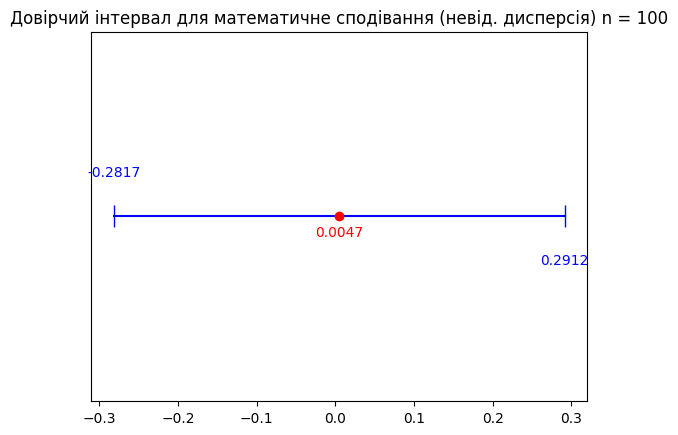

[Необхідно] Довірчий інтервал для математичного сподівання a при нормальному розподілі X але невідомій дисперсії sigma^2
____________________________________________________________________________________________________
[Кількість виконаних реалізацій] n = 10000
____________________________________________________________________________________________________
[Отримана оцінка] 0.01961142301804388
[Довірчий інтервал] [np.float64(-0.006389812435850812), np.float64(0.04561265847193857)]
[Ширина довірчого інтервалу] <__main__.InfoTask1 object at 0x00000192AA8E6660>
____________________________________________________________________________________________________




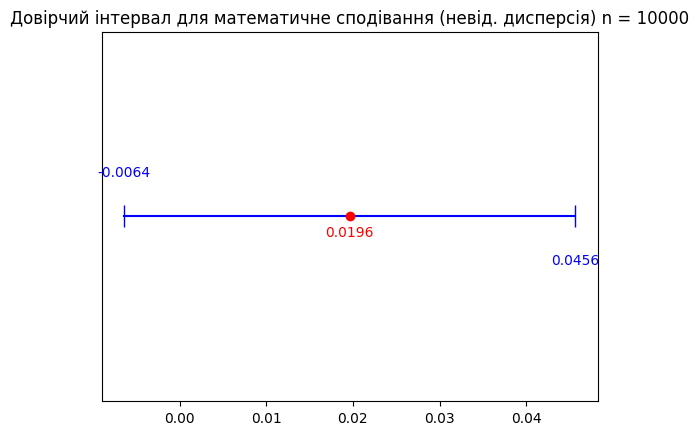

[Необхідно] Довірчий інтервал для математичного сподівання a при нормальному розподілі X але невідомій дисперсії sigma^2
____________________________________________________________________________________________________
[Кількість виконаних реалізацій] n = 1000000
____________________________________________________________________________________________________
[Отримана оцінка] -0.000330129873562466
[Довірчий інтервал] [np.float64(-0.00290521413104494), np.float64(0.0022449543839200077)]
[Ширина довірчого інтервалу] <__main__.InfoTask1 object at 0x00000192AA8E6660>
____________________________________________________________________________________________________




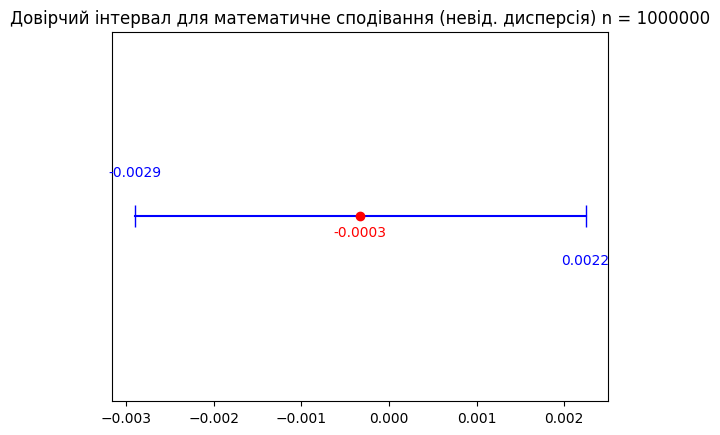



[Необхідно] Довірчий інтервал для математичного сподівання a при невідомому розподілі X
____________________________________________________________________________________________________
[Кількість виконаних реалізацій] n = 100
____________________________________________________________________________________________________
[Отримана оцінка] 0.11150231923123802
[Довірчий інтервал] [np.float64(-0.14080829518007562), np.float64(0.36381293364255163)]
[Ширина довірчого інтервалу] <__main__.InfoTask1 object at 0x00000192AA8E6660>
____________________________________________________________________________________________________




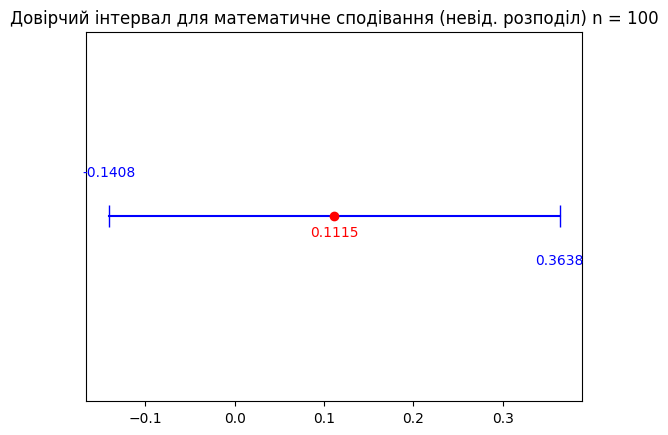

[Необхідно] Довірчий інтервал для математичного сподівання a при невідомому розподілі X
____________________________________________________________________________________________________
[Кількість виконаних реалізацій] n = 10000
____________________________________________________________________________________________________
[Отримана оцінка] -0.001078039631239055
[Довірчий інтервал] [np.float64(-0.02663985303422965), np.float64(0.02448377377175154)]
[Ширина довірчого інтервалу] <__main__.InfoTask1 object at 0x00000192AA8E6660>
____________________________________________________________________________________________________




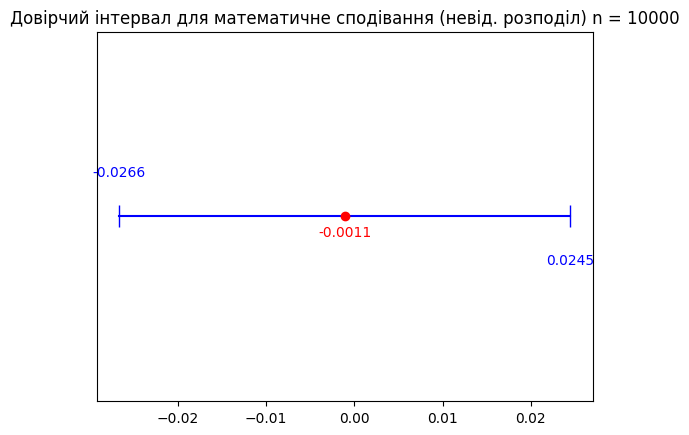

[Необхідно] Довірчий інтервал для математичного сподівання a при невідомому розподілі X
____________________________________________________________________________________________________
[Кількість виконаних реалізацій] n = 1000000
____________________________________________________________________________________________________
[Отримана оцінка] 0.0007103355178177639
[Довірчий інтервал] [np.float64(-0.0018675559442577865), np.float64(0.003288226979893314)]
[Ширина довірчого інтервалу] <__main__.InfoTask1 object at 0x00000192AA8E6660>
____________________________________________________________________________________________________




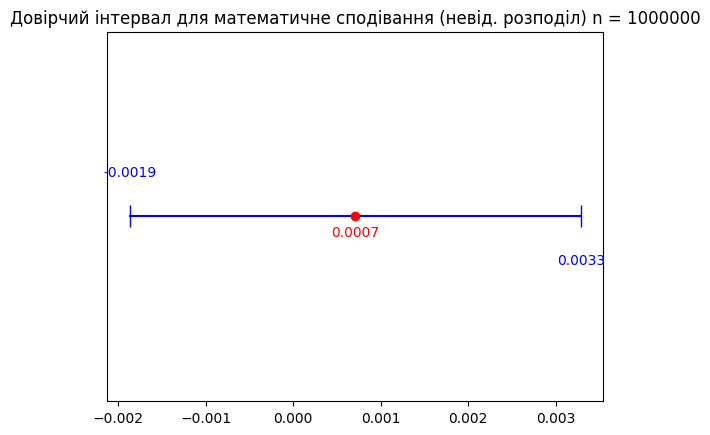



[Необхідно] Довірчий інтервал для дисперсії sigma^2 при нормальному розподілі X
____________________________________________________________________________________________________
[Кількість виконаних реалізацій] n = 100
____________________________________________________________________________________________________
[Отримана оцінка] 0.9466370453990894
[Довірчий інтервал] [np.float64(0.6810986065687603), np.float64(1.423298070427745)]
[Ширина довірчого інтервалу] <__main__.InfoTask1 object at 0x00000192AA8E6660>
____________________________________________________________________________________________________




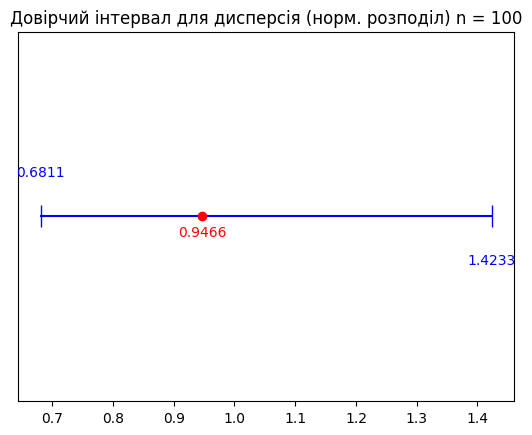

[Необхідно] Довірчий інтервал для дисперсії sigma^2 при нормальному розподілі X
____________________________________________________________________________________________________
[Кількість виконаних реалізацій] n = 10000
____________________________________________________________________________________________________
[Отримана оцінка] 1.021753100186637
[Довірчий інтервал] [np.float64(0.9855808215902706), np.float64(1.0600750027148957)]
[Ширина довірчого інтервалу] <__main__.InfoTask1 object at 0x00000192AA8E6660>
____________________________________________________________________________________________________




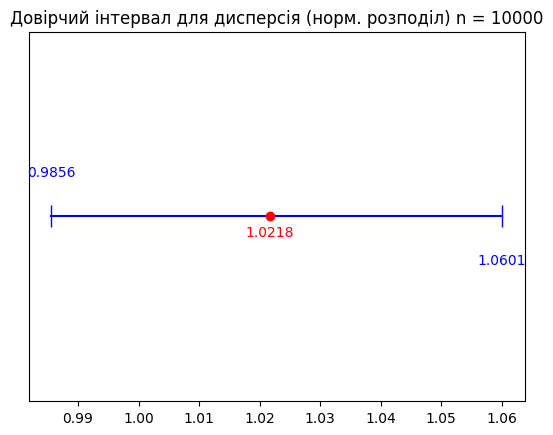

[Необхідно] Довірчий інтервал для дисперсії sigma^2 при нормальному розподілі X
____________________________________________________________________________________________________
[Кількість виконаних реалізацій] n = 1000000
____________________________________________________________________________________________________
[Отримана оцінка] 0.994932436177768
[Довірчий інтервал] [np.float64(0.9913185571786729), np.float64(0.9985672351364886)]
[Ширина довірчого інтервалу] <__main__.InfoTask1 object at 0x00000192AA8E6660>
____________________________________________________________________________________________________




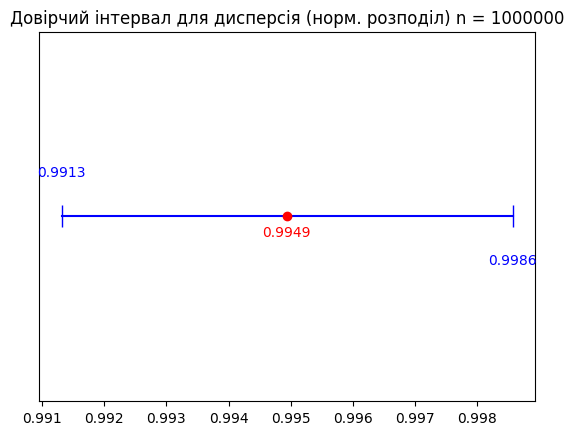

In [134]:
info = InfoTask1()
for info_index in range(len(infos)):
    info.title = infos[info_index]
    for n in numbers:
        info.n = n
        X = generate_data(n)
        
        X_mean = np.mean(X)
        X_var = np.var(X)
        X_var_d = np.var(X, ddof=1)
        if info_index != 2:
            info.estimation = X_mean
        else:
            info.estimation = X_var
        
        match info_index:
            case 0:
                normal_distribution_mean_estimation_without_known_variance(n, gamma, X_mean, np.sqrt(X_var), info)
                suptitle = "математичне сподівання (невід. дисперсія)"
            case 1:
                unknown_distribution_mean_estimation(n, gamma, X_mean, np.sqrt(X_var_d), info)
                suptitle = "математичне сподівання (невід. розподіл)"
            case 2:
                normal_distribution_var_estimation(n, gamma, X_var, info)
                suptitle = "дисперсія (норм. розподіл)"

        info.print_info(suptitle)
    print("="*100)
    print("\n")


# Завдання 2

## Опис

Обчислення ймовірності $Q_n = P\{ \xi_1 + K + \xi_2 \}$  трьома способами із дослідженням швидкості збіжності, тобто кількості реалізацій, витрачених різними алгоритмами на побудову оцінки із заданими достовірністю та відносною похибкою (інакше кажучи, виявлення найкращого методу для тих чи інших варіантів задачі).

Випадкові величини $\{ \xi_i \}$ є незалежними та однаково розподіленими (розподіл Вейбулла):
$$ F(u) = P\{ \xi_i < u \} = 1 - e^{-u^2}, u >= 0 $$

В.в. $ \eta $  може мати один з двох розподілів:
$$ \text{A. } G(u) = P\{ \eta < u \} = 1 - \frac{1}{(1 + u)^2}, u >= 0, M \eta = \int_0^{\inf}{[1 - G(u)]du} = \int_0^{\inf}{\frac{1}{(1 + u)^2} du} = 1 $$
$$ \text{B. } G(u) = P\{ \eta < u \} = 1 - e^{-u}, u >= 0, M \eta = \int_0^{\inf}{[1 - G(u)]du} = \int_0^{\inf}{e^{-u} du} = 1 $$

Зауваження 1. Нехай $ \omega, \omega_1, \omega_2, K $ - послідовність незалежних рівномірно розподілених на відрізку $ [0, 1] $ в.в. (послідовність псевдовипадкових чисел). Тоді моделювання в.в. $ \{ \xi_i \} $ та $ \eta $ відбувається за формулами:

$ \xi_i = F^{-1}(\omega_i), \text{ тобто } 1 - e^{-\xi_i^2} = 1 - \omega_i (\omega_i \text{ та } 1 - \omega_i \text{ мають один і той же рівномірний розподіл }) \Rightarrow \xi_i = (- \ln{\omega_i})^{1/2}; $

Випадок А:
$ \eta = G^{-1}(\omega) $, тобто $ 1 - \frac{1}{(1 + \eta)^2} = 1 - \omega \Rightarrow \eta = \frac{1}{\omega^{1/2}} - 1 $;

Випадок В:
$ \eta = G^{-1}(\omega) $, тобто $ 1 - e^{-\eta} = 1 - \omega \Rightarrow \eta = -\ln{\omega} $.

Зауваження 2. Загальна схема обчислення ймовірності $ Q_n $ виглядає наступним чином. Нехай $ \hat{q}_1, \hat{q}_2, K $ - незміщені оцінки ймовірності $ Q_n $.
Позначимо
$$ $$
- незміщена оцінка для $ Q_n $ та вибіркова дисперсія, побудовані за $ N $ реалізацій того чи іншого алгоритму.

Кількість реалізацій $ N^* $, які потрібно здійснити для обчислення ймовірності $ Q_n $ із заданими достовірністю $ 1 - \gamma $ та відносною похибкою $ \epsilon $ обчислюється за формулою:
$$ N^* = \min\{ N > N_0: N >= \frac{z_{\gamma}^2 \hat{\sigma}_n^2(N)}{\epsilon^2 \hat{Q}_n^2(N)} \}, $$
де $ N_0 $ - початкова кількість реалізацій, яка потрібна для “стабілізації” вибіркової дисперсії, а $ z_{\gamma} $ - це коефіцієнт, який знаходиться з рівняння $ 2 \Phi(z) = 1 - \gamma $ ($ \Phi(z) $ - це функція Лапласа).

В усіх наведених вище випадках обчислення вести із достовірністю 0.99 та відносною похибкою 1%, тобто $ z_{\gamma} = 2.575 $ і $ \epsilon = 0.01 $. Параметр $ n $ приймає наступні значення: 1, 10, 100, 200. В.в. $ \eta $ має один з двох розподілів (випадки А та В). Для обчислення $ Q_n $ використовуємо один з трьох методів статистичного моделювання та з’ясовуємо, який з них більш доцільно використовувати.

## Методи

**Метод 1.** Стандартний метод Монте-Карло:
$ Q_n = M I(\xi_1 + K + \xi_n < \eta) $, тобто $ \hat{q}_i = I(\xi_1^{(i)} + K + \xi_n^{(i)} < \eta_i) $,
де $ I(\dot) $ - індикаторна функція (індекс $ "i" $ відноситься до $ i $-ї реалізації алгоритму).

**Метод 2.** Використовуємо співвідношення:
$$ Q_n = \int_{0}^{\inf}{[1 - G(u)] dP\{ \xi_1 + K + \xi_n < u \}} = M[1 - G(\xi_1 + K + \xi_n)], $$
тобто
   $$ \hat{q}_i = \frac{1}{\left( 1 + \xi_1^{(i)} + K + \xi_n^{(i)} \right)^2} \text{ (випадок А);}$$
   $$ \hat{q}_i = e^{- \left( \xi_1^{(i)} + K + \xi_n^{(i)} \right)} \text{ (випадок В).}$$

**Метод 3.** Цей метод ґрунтується на формулі:
$$ Q_n = \int_{0}^{\inf}{P\{ \xi_1 + K + \xi_n < u \} dG(u)} = M_{\eta} P\{ \xi_1 + K + \xi_n < \eta \}. $$
Оскільки ймовірність $ P\{ \xi_1 + K + \xi_n < u \} $ не може бути обчисленою за явною аналітичною формулою (як у попередньому випадку), то для обчислення ймовірності $ P\{ \xi_1 + K + \xi_n < u \} $ (згортка) використовуємо наступний простий алгоритм побудови оцінки в одній реалізації.
1. Моделюємо значення в.в. $ \eta $. Нехай $ \eta = u $.
2. Як початкові значення виберемо: $ T = u, \hat{q} = 1 $ (початкова оцінка ймовірності $ P\{ \xi_1 + K + \xi_n < u \} $). 
3. У циклі $ n $ разів повторюємо наступні кроки алгоритму:
   - обчислюємо $ \gamma = P\{ \xi < T \} = 1 - e^{-T^2} $;
   - як нове значення для $ \hat{q} $ обираємо $ \hat{q} \cdot \gamma $;
   - моделюємо в.в. $ \xi^* $ з розподілом
   $$ P\{ \xi^* < \nu \} = P\{ \xi < \nu \vert \xi < T \} = \frac{1 - e^{-\nu^2}}{1 - e^{-T^2}}, \nu \in [0, T], $$
   а саме $ \xi^* = \left( -\ln \left( 1 - \omega \cdot \left( 1 - e^{-T^2} \right) \right) \right)^{1/2} $, де $ \omega $ має рівномірний розподіл на $ [0, 1] $;
   - замість $ T $ обираємо $ T - \xi^* $.
4. Коли цикл завершено, як оцінку для $ Q_n $ обираємо отримане значення $ \hat{q} $.

## Вимоги

$ z_{\gamma} = 2.575 $

$ 1 - \gamma = 0.99 $

Для кожного значення параметра $ n $ (1, 10, 100, 200), для випадків А та В для кожного з трьох методів виводити на друк:
- оцінку $ \hat{Q}_n(N^*) $;
- вибіркову дисперсію $ \hat{\sigma}_n^2(N^*)$;
- відповідний довірчий інтервал;
- кількість виконаних реалізацій $ N^* $, які знадобились для побудови оцінки із достовірністю 0.99 та відносною похибкою 1%

## Реалізація

In [135]:
class InfoTask2:
    def __init__(self, method: str = None, case: str = None, n: int = None, estimation: float = None, var: float = None, interval: list[float] = None, n_used: int = None):
        self.method = method
        self.case = case
        self.n = n
        self.estimation  = estimation
        self.var  = var
        self.interval = interval
        self.n_used = n_used

    def print_info(self):
        width_separate = 100
        print(self.method)
        print("_"*width_separate)
        print(f"[Випадок] {self.case}")
        print(f"[Кількість параметру n] {self.n}")
        print("_"*width_separate)
        print(f"[Отримана оцінка] {self.estimation}")
        print(f"[Отримана дисперсія] {self.var}")
        print(f"[Довірчий інтервал] {self.interval}")
        print(f"[Кількість виконаних реалізацій] {self.n_used}")
        print("_"*width_separate)
        print("\n")
        if self.interval:
            plt.ylim(-0.5, 0.5)
            plt.yticks([])
            plt.plot(self.interval, [0, 0], color='blue', zorder=1, marker='|', markersize=16)
            plt.scatter(self.estimation, 0, color='red', zorder=2)
            y_offset = 0.05 
            plt.text(self.interval[0], 2*y_offset, f"{self.interval[0]:.4f}", ha='center', va='bottom', color='blue')
            plt.text(self.interval[1], -2*y_offset, f"{self.interval[1]:.4f}", ha='center', va='top', color='blue')
            plt.text(self.estimation, -0.5*y_offset, f"{self.estimation:.4f}", ha='center', va='top', color='red')
            plt.title(f"Довірчий інтервал для {self.method} Випадок {self.case} n = {self.n}")
            plt.show()

In [136]:
def generate_xi(size):
    omega = np.random.uniform(0, 1, size)
    return np.sqrt(-np.log(omega))

def generate_eta(info: InfoTask2, size):
    omega = np.random.uniform(0, 1, size)  #, info.n
    match info.case:
        case 'A':
            return 1.0 / np.sqrt(omega) - 1.0
        case 'B':
            return -np.log(omega)

def monte_carlo_method(info: InfoTask2):
    xi_sum = sum(generate_xi(info.n))
    eta = generate_eta(info, 1)
    # print(xi_sum < eta)
    q_i = 1 if xi_sum < eta else 0
    return q_i

Метод 1
____________________________________________________________________________________________________
[Випадок] A
[Кількість параметру n] 1
____________________________________________________________________________________________________
[Отримана оцінка] 0.33503286349302835
[Отримана дисперсія] 0.22278753672278498
[Довірчий інтервал] [np.float64(0.33168254199208796), np.float64(0.33838318499396874)]
[Кількість виконаних реалізацій] 131605
____________________________________________________________________________________________________




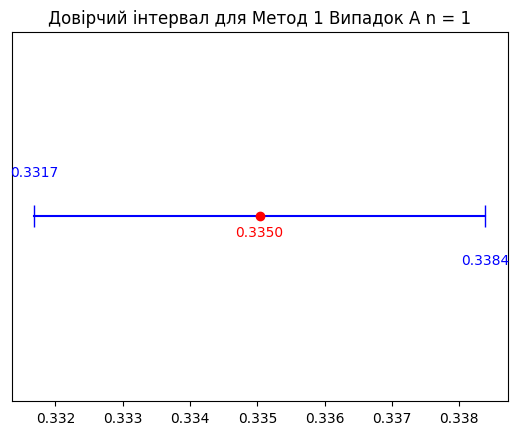

Метод 1
____________________________________________________________________________________________________
[Випадок] A
[Кількість параметру n] 10
____________________________________________________________________________________________________
[Отримана оцінка] None
[Отримана дисперсія] None
[Довірчий інтервал] None
[Кількість виконаних реалізацій] None
____________________________________________________________________________________________________


Метод 1
____________________________________________________________________________________________________
[Випадок] A
[Кількість параметру n] 100
____________________________________________________________________________________________________
[Отримана оцінка] None
[Отримана дисперсія] None
[Довірчий інтервал] None
[Кількість виконаних реалізацій] None
____________________________________________________________________________________________________




KeyboardInterrupt: 

In [137]:
epsilon = 0.01
confidence_level = 0.99
gamma = 1 - confidence_level

z_value = 2.575

n_max = 5 * 10**5

methods = ["Метод 1", "Метод 2", "Метод 3"]
cases = ["A", "B"]
ns = [1, 10, 100, 200]

for method in methods:
    info.method = method
    for cas in cases:
        info.case = cas
        for n in ns:
            info.n = n

            # TODO: REDO
            N = 0
            sum_q = 0.0
            sum_q2 = 0.0

            while True:
                N += 1
                match methods.index(method):
                    case 0:
                        q_i = monte_carlo_method(info)
                    case 1:
                        pass
                    case 2:
                        pass
                if q_i != 0 and N > 1:
                    sum_q += q_i
                    sum_q2 += q_i**2

                    Q_est = sum_q / N
                    # Несмещенная выборочная дисперсия
                    var_est = (sum_q2 - N * (Q_est**2)) / (N - 1)
                    
                    if Q_est > 0:
                        required_N = (z_value**2 * var_est) / (epsilon**2 * Q_est**2)
                        if N >= required_N:
                            margin = z_value * np.sqrt(var_est / N)
                            interval = [Q_est - margin, Q_est + margin]
                            info = InfoTask2(method, cas, n, estimation=Q_est, var=var_est, interval=interval, n_used=N)
                            info.print_info()
                            break
                            
                    if N >= n_max:
                        info = InfoTask2(method, cas, n)
                        info.print_info()
                        break
    
